In [7]:
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("songs_normalize.csv", low_memory=False)

#Show entire dataset
print(df.head())
#Show column names
print(df.columns)   

print(df.shape)

df.isnull().sum()

           artist                    song  duration_ms  explicit  year  \
0  Britney Spears  Oops!...I Did It Again       211160     False  2000   
1       blink-182    All The Small Things       167066     False  1999   
2      Faith Hill                 Breathe       250546     False  1999   
3        Bon Jovi            It's My Life       224493     False  2000   
4          *NSYNC             Bye Bye Bye       200560     False  2000   

   popularity  danceability  energy  key  loudness  mode  speechiness  \
0          77         0.751   0.834    1    -5.444     0       0.0437   
1          79         0.434   0.897    0    -4.918     1       0.0488   
2          66         0.529   0.496    7    -9.007     1       0.0290   
3          78         0.551   0.913    0    -4.063     0       0.0466   
4          65         0.614   0.928    8    -4.806     0       0.0516   

   acousticness  instrumentalness  liveness  valence    tempo         genre  \
0        0.3000          0.000018    

artist              0
song                0
duration_ms         0
explicit            0
year                0
popularity          0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
genre               0
mood                0
dtype: int64

In [8]:
print(df["mood"].unique())


['Joyful' 'Energetic' 'Melancholic' 'Emotional' 'Powerful' 'Soothing'
 'Calm']


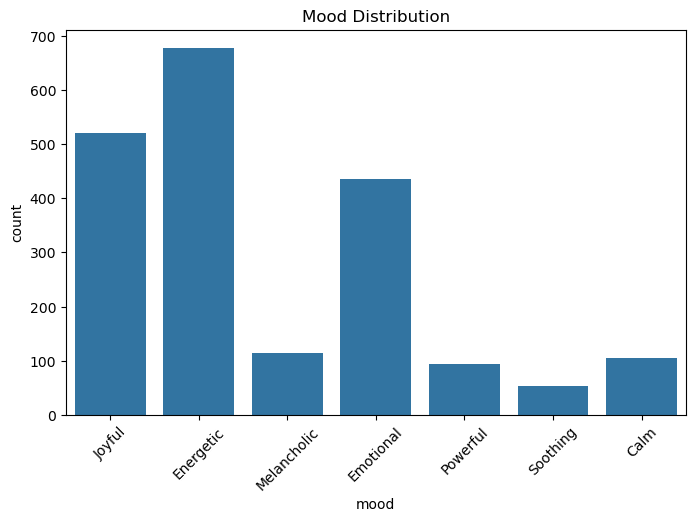

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

df["mood"].value_counts()

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="mood")
plt.xticks(rotation=45)
plt.title("Mood Distribution")
plt.show()


loudness vs energy correlation: 0.6510155228369133


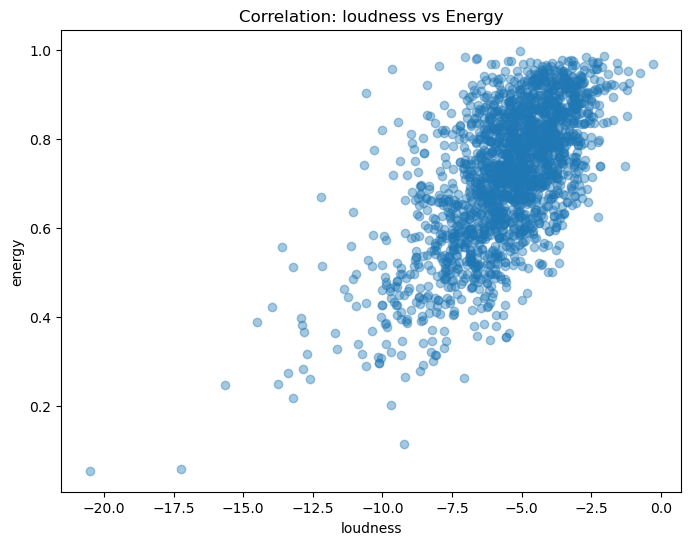

--- Regression (loudness) ---
Intercept: 1.0038721350048279
Slope: 0.05143029545381954
R-squared: 0.42382121097461944


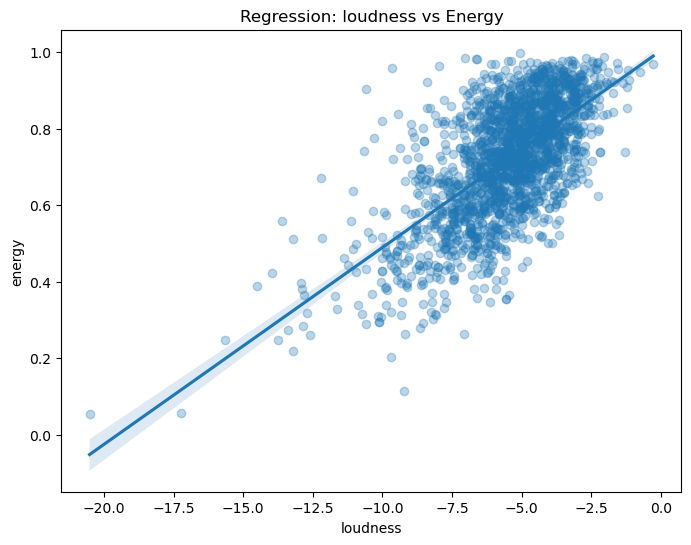


danceability vs energy correlation: -0.10403836408435754


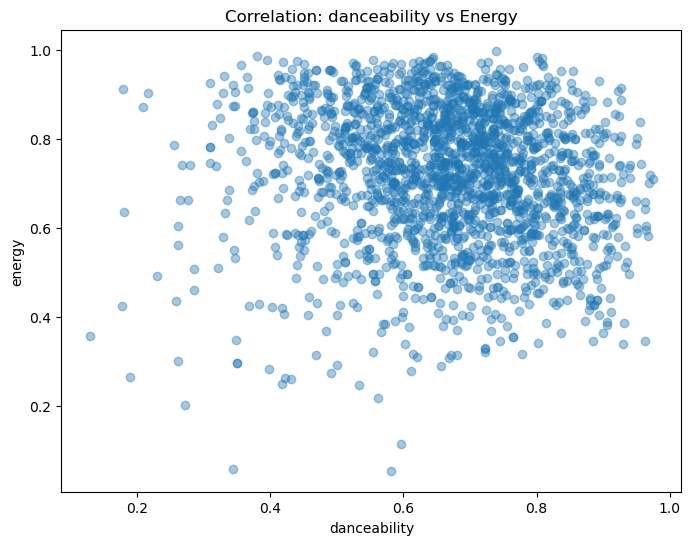

--- Regression (danceability) ---
Intercept: 0.7959020117456731
Slope: -0.11317316115092901
R-squared: 0.01082398120134942


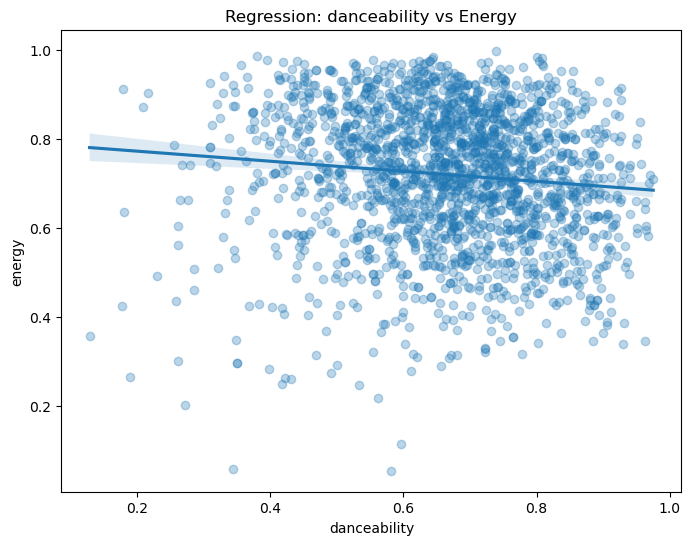


valence vs energy correlation: 0.3344744311237129


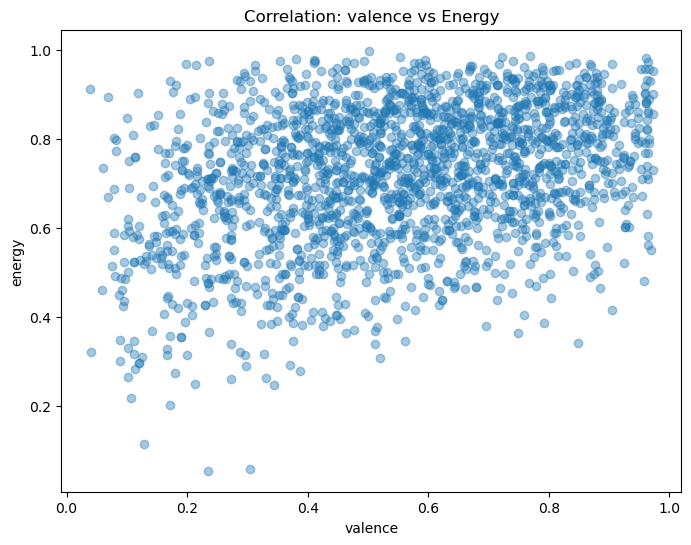

--- Regression (valence) ---
Intercept: 0.5927514288851206
Slope: 0.23131586955615244
R-squared: 0.11187314507553137


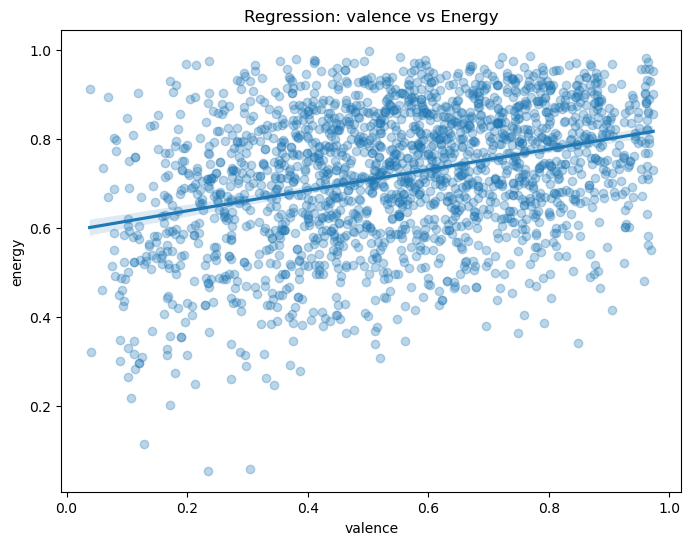


acousticness vs energy correlation: -0.4454685177458775


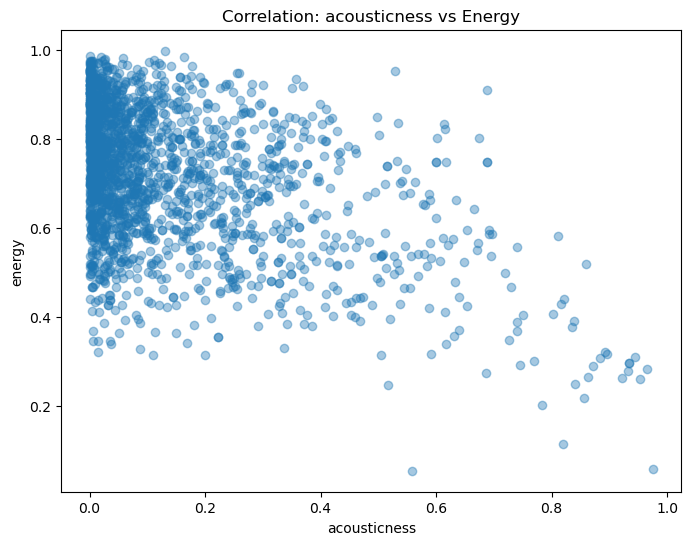

--- Regression (acousticness) ---
Intercept: 0.770984483725113
Slope: -0.39252849448870525
R-squared: 0.19844220030270887


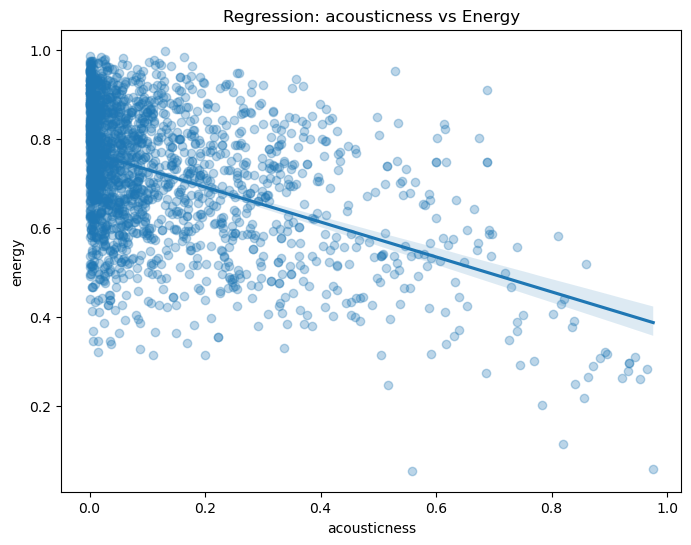

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = df.dropna(subset=["energy","loudness","danceability","valence","acousticness"])

features = ["loudness","danceability","valence","acousticness"]

for feature in features:
    
    # -----------------------
    # CORRELATION
    # -----------------------
    corr = df[feature].corr(df["energy"])
    print(f"\n{feature} vs energy correlation:", corr)

    plt.figure(figsize=(8,6))
    plt.scatter(df[feature], df["energy"], alpha=0.4)
    plt.xlabel(feature)
    plt.ylabel("energy")
    plt.title(f"Correlation: {feature} vs Energy")
    plt.show()

    # -----------------------
    # REGRESSION
    # -----------------------
    X = df[[feature]]
    y = df["energy"]

    model = LinearRegression()
    model.fit(X, y)

    y_pred = model.predict(X)

    print(f"--- Regression ({feature}) ---")
    print("Intercept:", model.intercept_)
    print("Slope:", model.coef_[0])
    print("R-squared:", r2_score(y, y_pred))

    plt.figure(figsize=(8,6))
    sns.regplot(x=feature, y="energy", data=df, scatter_kws={"alpha":0.3})
    plt.title(f"Regression: {feature} vs Energy")
    plt.xlabel(feature)
    plt.ylabel("energy")
    plt.show()

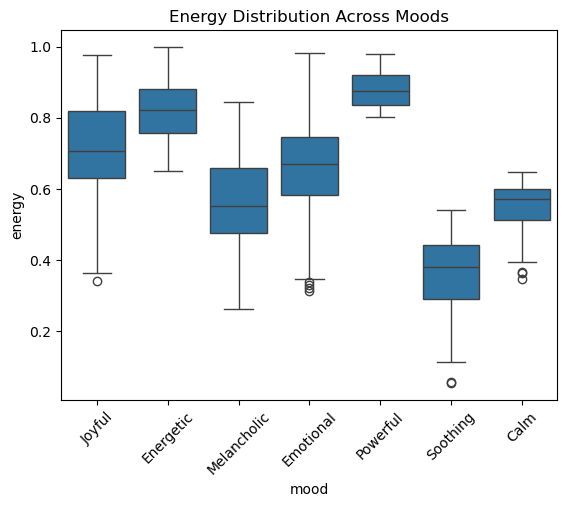

In [14]:
sns.boxplot(data=df, x="mood", y="energy")
plt.xticks(rotation=45)
plt.title("Energy Distribution Across Moods")
plt.show()

In [1]:
def predict_mood(row):
    if row["energy"] > 0.7 and row["valence"] > 0.6:
        return "Happy"
    elif row["energy"] < 0.4 and row["valence"] < 0.4:
        return "Sad"
    else:
        return "Neutral"

df["predicted_mood"] = df.apply(predict_mood, axis=1)

NameError: name 'df' is not defined